### UCU | Maestría en Ciencia de Datos | Aprendizaje Automático | Walter D. Soriano Vaio

# Reposición Inteligente de Inventario (RII)

**Objetivo del trabajo:** desarrollar una solución de Machine Learning que apoye la decisión de reposición de inventario, combinando:

- **Eje 1 --> Segmentación estratégica:** identificar agrupamientos naturales de productos según margen y rotación y contrastarlos con la clasificación clásica A/B/C del negocio
- **Eje 2 --> Predicción de demanda:** estimar la demanda mensual de cada producto a partir de su comportamiento histórico.
- **Eje 3 --> Propuesta de reposición trimestral: proyectar la demanda a 3 meses y traducirla en una propuesta concreta de qué reponer, priorizando por rentabilidad (GMROI) y respetando la capacidad del camión (8 toneladas por envío)

**Fuente de datos:** historial real de ventas, stock, costos y precios de productos en el período enero-julio 2026


## 1. Importación de Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import silhouette_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 2. Fuente de Datos

Dataset real con historial de ventas y stock por producto


In [ ]:
url = "https://raw.githubusercontent.com/wdsoriano/InventoryAnalytics/main/dataset.csv"
df = pd.read_csv(url, encoding="latin1")
df["Fecha"] = pd.to_datetime(df["Fecha"], dayfirst=True, errors="coerce")

print(f"Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}")
df.head()


Filas: 58,643  |  Columnas: 26


,Fecha,Codigo,Codigo Barras,Grupo,Marca,Peso Grs,Impuesto Factor,Costo Logistico USD,Costo CIF Unidad USD,Costo Final Unidad USD,Precio Lista Unidad USD,Utilidad Unidad USD,Margen Unidad %,Venta Precio Unidad USD,Venta Bruta USD,Venta Descuento USD,Venta Neta USD,Venta Costo CIF USD,Venta Impuesto USD,Venta Costo Final USD,Venta Utilidad USD,Venta Cantidad UNI,Stock Promedio UNI,Venta Acumulada UNI,Stock Cantidad UNI,Stock Rotacion UNI
0,2026-01-01,72,50036398831,ELETRONICA,JBL,170.0,0.1028,1.90,63.34,69.85,112.2,42.35,37.74,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,9,0,14,0.0
1,2026-01-01,74,50036403047,ELETRONICA,JBL,1680.0,0.1028,1.91,63.68,70.22,102.0,31.78,31.15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,4,0,6,0.0
2,2026-01-01,77,1200130020940,ELETRONICA,JBL,930.0,0.1028,5.93,197.76,218.09,308.0,89.91,29.19,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,8,0,12,0.0
3,2026-01-01,80,50036412285,ELETRONICA,JBL,80.0,0.1028,0.66,22.07,24.34,103.0,78.66,76.37,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,32,0,50,0.0
4,2026-01-01,111,5000159559447,COMESTIVEIS,TWIX,500.0,0.1028,0.26,8.66,9.55,9.2,-0.35,-3.81,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,20,0,30,0.0


## 3. Análisis Exploratorio de Datos

3.1 Calidad de los datos: tipos de datos, nulos y duplicados

In [ ]:
print("Tipos de datos")
print("")
print(df.dtypes.value_counts())

print("")
print("Valores nulos totales -->", df.isnull().sum().sum())
print("Filas duplicadas      -->", df.duplicated().sum())
print(f"Productos únicos      --> {df['Codigo'].nunique():,}")
print(f"Fechas únicas         --> {df['Fecha'].nunique()}")
print(f"Grupos de producto    --> {df['Grupo'].nunique()}")


Tipos de datos

float64           17
int64              6
object             2
datetime64[ns]     1
Name: count, dtype: int64

Valores nulos totales --> 0
Filas duplicadas      --> 0
Productos únicos      --> 8,309
Fechas únicas         --> 205
Grupos de producto    --> 8


### 3.2 Granularidad de los datos

Dataset disperso: hay muchos productos con pocas observaciones en el período de muestra


count    8309.000000
mean        7.057769
std        14.201319
min         1.000000
25%         1.000000
50%         2.000000
75%         6.000000
max       199.000000
dtype: float64



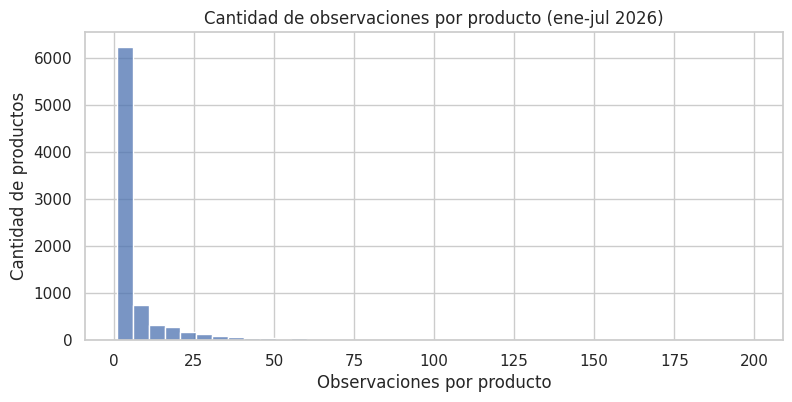

In [ ]:
obs_por_producto = df.groupby("Codigo").size()
print(obs_por_producto.describe())
print("")

plt.figure(figsize=(9, 4))
sns.histplot(obs_por_producto, bins=40)
plt.title("Cantidad de observaciones por producto (ene-jul 2026)")
plt.xlabel("Observaciones por producto")
plt.ylabel("Cantidad de productos")
plt.show()


### 3.3 Distribuciones de ventas y stock

Venta Cantidad UNI

count    58643.000000
mean         2.373003
std          6.011305
min         -4.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        489.000000
Name: Venta Cantidad UNI, dtype: float64

Registros con Venta negativa   -->  52
Registros con Margen negativo  -->  187



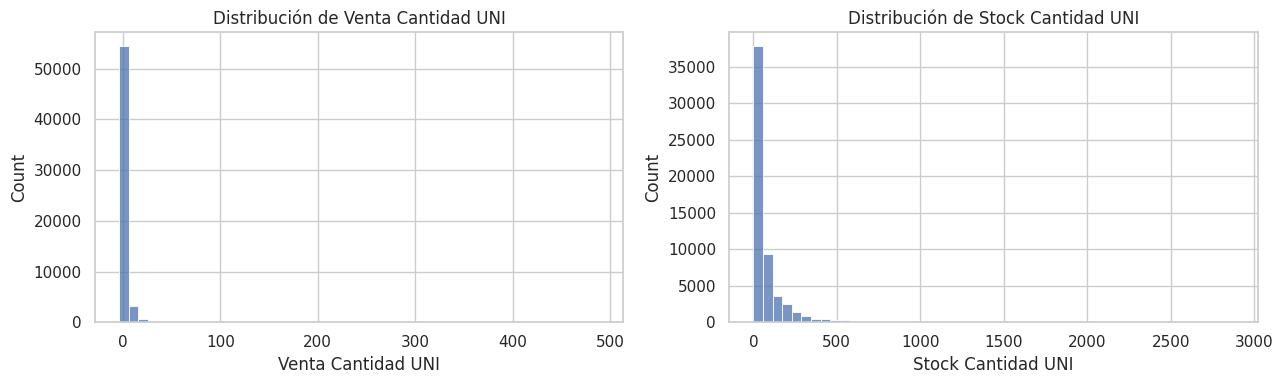

In [ ]:
print("Venta Cantidad UNI")
print("")
print(df["Venta Cantidad UNI"].describe())

print("")
print("Registros con Venta negativa   --> ", (df["Venta Cantidad UNI"] < 0).sum())
print("Registros con Margen negativo  --> ", (df["Margen Unidad %"] < 0).sum())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["Venta Cantidad UNI"], bins=50, ax=axes[0])
axes[0].set_title("Distribución de Venta Cantidad UNI")
sns.histplot(df["Stock Cantidad UNI"], bins=50, ax=axes[1])
axes[1].set_title("Distribución de Stock Cantidad UNI")
plt.tight_layout()

print("")
plt.show()


Nota: existen casos de Ventas en negativo (devoluciones) y casos con Margen en negativo (precios especiales). Son situaciones reales del negocio


### 3.4 Ventas por Grupo de producto

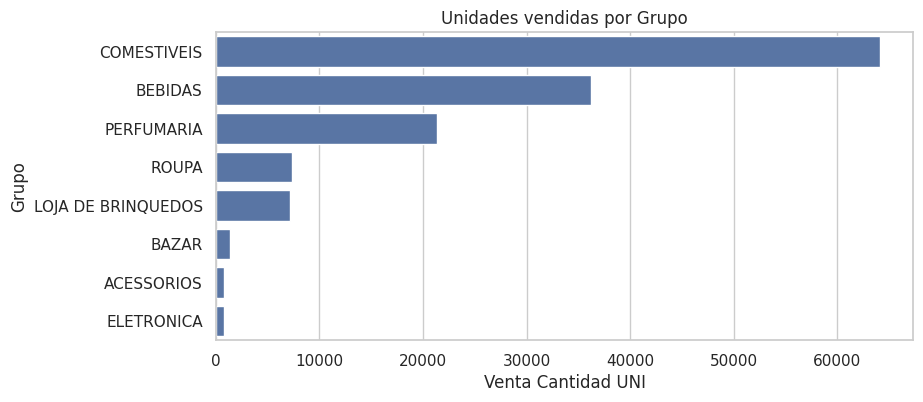


Grupo
COMESTIVEIS           46.1
BEBIDAS               26.0
PERFUMARIA            15.3
ROUPA                  5.3
LOJA DE BRINQUEDOS     5.1
BAZAR                  1.0
ACESSORIOS             0.6
ELETRONICA             0.6
Name: Venta Cantidad UNI, dtype: float64


In [ ]:
ventas_grupo = df.groupby("Grupo")["Venta Cantidad UNI"].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 4))
sns.barplot(x=ventas_grupo.values, y=ventas_grupo.index)
plt.title("Unidades vendidas por Grupo")
plt.xlabel("Venta Cantidad UNI")
plt.show()

print("")
print((ventas_grupo / ventas_grupo.sum() * 100).round(1))


Hay una fuerte concentración en los grupos COMESTIVEIS y PERFUMARIA y muy poco peso en ELETRONICA. Este desbalance se tiene en cuenta más adelante: el modelo de demanda se entrena de forma global (pooled) para que los grupos chicos también aporten señal, en vez de un modelo por grupo


### 3.5 Correlaciones entre variables numéricas

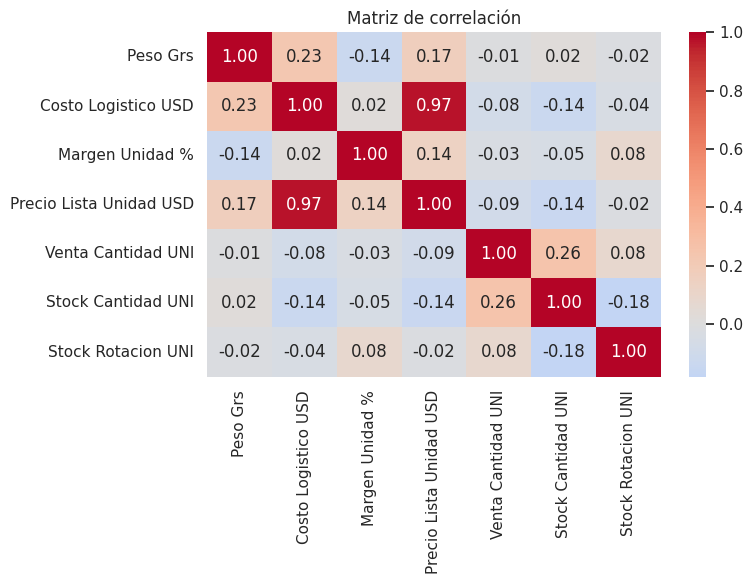

In [ ]:
variables_num = ["Peso Grs", "Costo Logistico USD", "Margen Unidad %",
                  "Precio Lista Unidad USD", "Venta Cantidad UNI",
                  "Stock Cantidad UNI", "Stock Rotacion UNI"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[variables_num].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()


## 4. Feature Engineering y Preprocesamiento

Las variables 'Venta Acumulada UNI' y 'Stock Promedio UNI' son valores acumulados desde el 01/01/2026 que fue la fecha de comienzo de la operación hasta el 31/07/2026. Esto puede generar un sesgo ya que un producto con más días registrados acumula más venta solo por el paso del tiempo no porque rote más rápido

Solución propuesta:
- Se recalculan las variables de negocio (venta total, stock promedio, rotación y GMROI) usando una **ventana de calendario fija**, igual para todos los productos, en vez del campo acumulado. Esto también evita *data leakage*: las features de un producto solo usan información anterior al mes que se quiere predecir

- Set de Entrenamiento: features con datos de enero a mayo --> predicen la demanda de junio.
- Set de Prueba: features con datos de enero a junio --> predicen la demanda de julio (mes para el que se arma la propuesta de reposición)


In [ ]:
def construir_features(df, fecha_inicio, fecha_fin_exclusiva):
    """Calcula variables de producto usando solo movimientos dentro de [fecha_inicio, fecha_fin_exclusiva)"""
    ventana = df[(df["Fecha"] >= fecha_inicio) & (df["Fecha"] < fecha_fin_exclusiva)]

    feats = ventana.groupby("Codigo").agg(
        Grupo=("Grupo", "first"),
        Peso_Grs=("Peso Grs", "first"),
        Margen_Pct=("Margen Unidad %", "first"),
        Costo_Logistico_USD=("Costo Logistico USD", "first"),
        Costo_Final_USD=("Costo Final Unidad USD", "first"),
        Precio_Lista_USD=("Precio Lista Unidad USD", "first"),
        Venta_Ventana_UNI=("Venta Cantidad UNI", "sum"),
        Utilidad_Ventana_USD=("Venta Utilidad USD", "sum"),
        Stock_Prom_Ventana=("Stock Cantidad UNI", "mean"),
        Stock_Actual=("Stock Cantidad UNI", "last"),
        N_Obs_Ventana=("Codigo", "size"),
    )

    # Rotación y GMROI recalculados sobre la ventana de calendario fija

    feats["Rotacion_Ventana"] = feats["Venta_Ventana_UNI"] / feats["Stock_Prom_Ventana"].replace(0, np.nan)
    feats["GMROI"] = feats["Utilidad_Ventana_USD"] / (
        feats["Stock_Prom_Ventana"] * feats["Costo_Final_USD"]
    ).replace(0, np.nan)

    # Imputación simple (mediana): stock promedio 0 deja Rotación/GMROI indefinidos

    for col in ["Rotacion_Ventana", "GMROI"]:
        feats[col] = feats[col].fillna(feats[col].median())

    return feats

def demanda_mes(df, anio_mes):
    """Unidades totales vendidas por producto en un mes calendario (variable objetivo)"""
    sub = df[df["Fecha"].dt.to_period("M") == anio_mes]
    return sub.groupby("Codigo")["Venta Cantidad UNI"].sum().rename("Demanda_Real")

train = construir_features(df, "2026-01-01", "2026-06-01").join(demanda_mes(df, "2026-06"), how="left")
train["Demanda_Real"] = train["Demanda_Real"].fillna(0)

test = construir_features(df, "2026-01-01", "2026-07-01").join(demanda_mes(df, "2026-07"), how="left")
test["Demanda_Real"] = test["Demanda_Real"].fillna(0)

print(f"Entrenamiento (features ene-may, target junio) --> {train.shape[0]:,} productos")
print(f"Prueba  (features ene-jun, target julio)       --> {test.shape[0]:,} productos")

# Productos que aparecen recién en julio 2026 no tienen historial lo que significa que no se pueden predecir

productos_nuevos_julio = set(df["Codigo"].unique()) - set(test.index)
print(f"Productos sin historial previo a julio 2026    --> {len(productos_nuevos_julio):,} productos (fuera del alcance del modelo)")
print("")
train.head()


Entrenamiento (features ene-may, target junio) --> 6,387 productos
Prueba  (features ene-jun, target julio)       --> 7,068 productos
Productos sin historial previo a julio 2026    --> 1,241 productos (fuera del alcance del modelo)



,Grupo,Peso_Grs,Margen_Pct,Costo_Logistico_USD,Costo_Final_USD,Precio_Lista_USD,Venta_Ventana_UNI,Utilidad_Ventana_USD,Stock_Prom_Ventana,Stock_Actual,N_Obs_Ventana,Rotacion_Ventana,GMROI,Demanda_Real
Codigo,,,,,,,,,,,,,,
27,ELETRONICA,200.0,22.77,0.87,31.82,41.2,9,115.62,95.000000,91,9,0.094737,0.038248,5.0
28,LOJA DE BRINQUEDOS,170.0,41.46,0.28,10.30,17.6,2,13.31,10.500000,10,2,0.190476,0.123070,0.0
29,LOJA DE BRINQUEDOS,170.0,42.98,0.30,11.18,19.6,6,40.62,10.500000,8,6,0.571429,0.346026,0.0
30,LOJA DE BRINQUEDOS,170.0,42.98,0.30,11.18,19.6,4,24.59,15.500000,14,4,0.258065,0.141901,0.0
31,LOJA DE BRINQUEDOS,170.0,42.98,0.30,11.18,19.6,4,31.13,15.333333,14,3,0.260870,0.181594,1.0


**Nota:** La variable 'Marca' se excluye por alta cardinalidad


In [ ]:
NUM_COLS = ["Peso_Grs", "Margen_Pct", "Costo_Logistico_USD", "Costo_Final_USD",
            "Precio_Lista_USD", "Venta_Ventana_UNI", "Stock_Prom_Ventana",
            "N_Obs_Ventana", "Rotacion_Ventana", "GMROI"]
CAT_COLS = ["Grupo"]

X_train, y_train = train[NUM_COLS + CAT_COLS], train["Demanda_Real"]
X_test, y_test = test[NUM_COLS + CAT_COLS], test["Demanda_Real"]

# Pipeline de preprocesamiento: se ajusta SOLO con 'train' y se aplica igual a 'test' sin fuga de datos

preprocesador = ColumnTransformer([
    ("num", StandardScaler(), NUM_COLS),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
])


## 5. Eje 1 — Segmentación de productos

Se evalúa si existen agrupamientos naturales de productos según las variables 'Margen Unidad %' y 'Venta Rotación UNI'. No se imponen grupos de antemano la idea es que el modelo los descubra


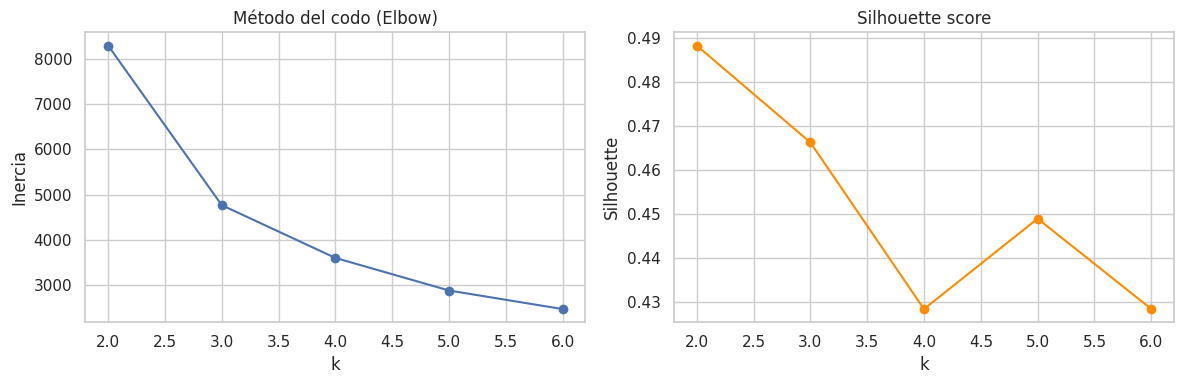

,k,inercia,silhouette
0,2,8287.881784,0.488332
1,3,4765.070962,0.466277
2,4,3600.410007,0.428361
3,5,2881.451490,0.448940
4,6,2471.690150,0.428378


In [ ]:
seg_scaled = StandardScaler().fit_transform(test[["Margen_Pct", "Rotacion_Ventana"]])

rango_k = range(2, 7)
inercia, silueta = [], []
for k in rango_k:
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10).fit(seg_scaled)
    inercia.append(km_k.inertia_)
    silueta.append(silhouette_score(seg_scaled, km_k.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(rango_k), inercia, marker="o")
axes[0].set_title("Método del codo (Elbow)")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inercia")
axes[1].plot(list(rango_k), silueta, marker="o", color="darkorange")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.show()

print("")
pd.DataFrame({"k": list(rango_k), "inercia": inercia, "silhouette": silueta})


Se evalúan valores de k entre 2 y 6 mediante Silhouette Score, inercia y tamaño mínimo de los clusters. Aunque k=2 presenta la mejor separación, k=3 mantiene una calidad de agrupamiento razonable y genera segmentos suficientemente diferenciados. Se selecciona k=3 porque permite una correspondencia directa con el esquema de cuadrantes A/B/C ampliamente utilizado en retail, facilitando la interpretación de los resultados y su aplicación en la toma de decisiones por parte de los analistas comerciales

,Margen_Prom,Rotacion_Prom,GMROI_Prom,N_Productos
Cluster,,,,
1,55.124032,3.720993,4.243261,1488
0,53.350865,0.656417,0.625298,3628
2,33.440272,0.969197,0.390031,1952


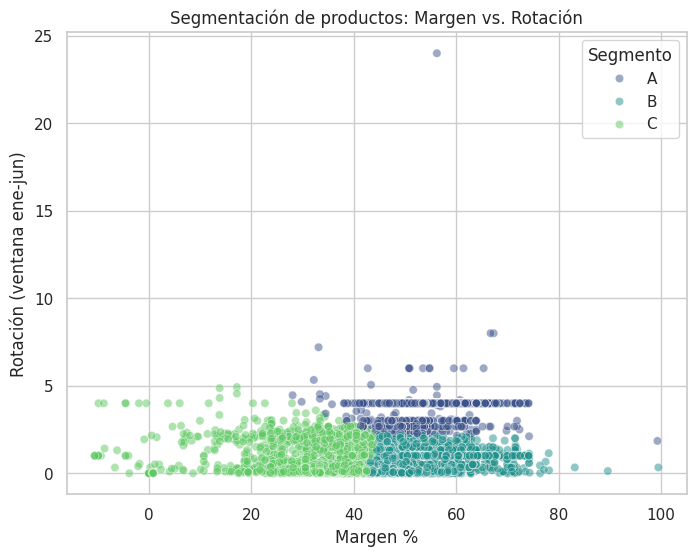

In [ ]:
K_ELEGIDO = 3
km_final = KMeans(n_clusters=K_ELEGIDO, random_state=42, n_init=10)
test["Cluster"] = km_final.fit_predict(seg_scaled)

# GMROI ganado (winsorizado al percentil 99 para no dejar que un outlier extremo domine el análisis)

test["GMROI_wins"] = test["GMROI"].clip(upper=test["GMROI"].quantile(0.99))

resumen_clusters = test.groupby("Cluster").agg(
    Margen_Prom=("Margen_Pct", "mean"),
    Rotacion_Prom=("Rotacion_Ventana", "mean"),
    GMROI_Prom=("GMROI_wins", "mean"),
    N_Productos=("Cluster", "size"),
).sort_values("GMROI_Prom", ascending=False)

# Etiquetado A/B/C segun ranking de GMROI promedio (A = mejor combinacion margen+rotacion)

etiquetas = dict(zip(resumen_clusters.index, ["A", "B", "C"]))
test["Segmento"] = test["Cluster"].map(etiquetas)

display(resumen_clusters)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=test, x="Margen_Pct", y="Rotacion_Ventana", hue="Segmento",
                 hue_order=["A", "B", "C"], alpha=0.5, palette="viridis")
plt.title("Segmentación de productos: Margen vs. Rotación")
plt.xlabel("Margen %")
plt.ylabel("Rotación (ventana ene-jun)")
print("")
plt.show()


El segmento A agrupa productos con mejor combinación de margen y rotación y mayor GMROI promedio. Son productos que deben priorizarse en el abastecimiento


## 6. Eje 2 — Predicción de la demanda

Se comparan: Baseline ingenuo, Regresión Lineal, Random Forest y KNN


,Modelo,Mejores_Hiperparametros,MAE,RMSE,R2
0,Regresion Lineal,{},3.151697,17.247432,0.231128
1,Random Forest,"{'modelo__max_depth': 5, 'modelo__n_estimators...",2.947861,16.586461,0.288930
2,KNN,"{'modelo__n_neighbors': 20, 'modelo__weights':...",2.719965,17.682111,0.191885
3,Baseline ingenuo (promedio historico),-,3.674071,18.193063,NaN


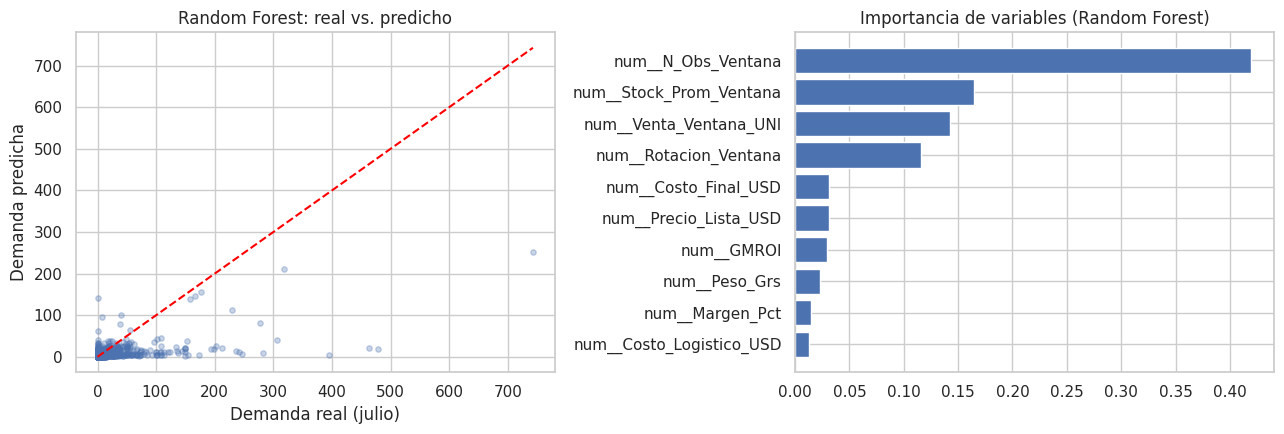

In [ ]:
# Baseline ingenuo --> promedio mensual historico de la propia ventana

pred_naive = test["Venta_Ventana_UNI"] / 6
mae_naive = mean_absolute_error(y_test, pred_naive)
rmse_naive = np.sqrt(mean_squared_error(y_test, pred_naive))

modelos = {
    "Regresion Lineal": (
        Pipeline([("prep", preprocesador), ("modelo", LinearRegression())]),
        {},
    ),
    "Random Forest": (
        Pipeline([("prep", preprocesador), ("modelo", RandomForestRegressor(random_state=42))]),
        {"modelo__n_estimators": [100, 300], "modelo__max_depth": [5, 10, None]},
    ),
    "KNN": (
        Pipeline([("prep", preprocesador), ("modelo", KNeighborsRegressor())]),
        {"modelo__n_neighbors": [5, 10, 20], "modelo__weights": ["uniform", "distance"]},
    ),
}

filas, modelos_ajustados = [], {}
for nombre, (pipe, grid) in modelos.items():
    gs = GridSearchCV(pipe, grid, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1)
    gs.fit(X_train, y_train)
    modelos_ajustados[nombre] = gs.best_estimator_

    pred = np.clip(gs.best_estimator_.predict(X_test), 0, None)  # nota: la demanda no puede ser negativa
    filas.append({
        "Modelo": nombre,
        "Mejores_Hiperparametros": gs.best_params_,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred),
    })

tabla_modelos = pd.DataFrame(filas)
tabla_modelos.loc[len(tabla_modelos)] = ["Baseline ingenuo (promedio historico)", "-", mae_naive, rmse_naive, np.nan]
display(tabla_modelos)

MODELO_FINAL = "Random Forest"
modelo_elegido = modelos_ajustados[MODELO_FINAL]

test["Demanda_Predicha"] = np.round(np.clip(modelo_elegido.predict(X_test), 0, None), 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(test["Demanda_Real"], test["Demanda_Predicha"], alpha=0.3, s=15)
lim = max(test["Demanda_Real"].max(), test["Demanda_Predicha"].max())
axes[0].plot([0, lim], [0, lim], color="red", linestyle="--")
axes[0].set_xlabel("Demanda real (julio)")
axes[0].set_ylabel("Demanda predicha")
axes[0].set_title(f"{MODELO_FINAL}: real vs. predicho")

importancias = pd.Series(
    modelo_elegido.named_steps["modelo"].feature_importances_,
    index=modelo_elegido.named_steps["prep"].get_feature_names_out(),
).sort_values(ascending=False).head(10)
axes[1].barh(importancias.index[::-1], importancias.values[::-1])
axes[1].set_title("Importancia de variables (Random Forest)")

plt.tight_layout()
plt.show()


Conclusión: Los tres modelos superan al baseline ingenuo en MAE y RMSE. Random Forest ofrece el mejor equilibrio entre error (MAE y RMSE) y capacidad explicativa además de ser interpretable mediante importancia de variables por eso se elige como modelo final para la propuesta de reposición aunque KNN tenga un MAE ligeramente menor


## 7. Eje 3 — Reposición trimestral

Se arma una propuesta de reposición que cubre 3 meses de demanda proyectada (julio-agosto-septiembre) para hacer un uso más realista del camión y reducir la frecuencia de envíos ahorrando en gastos logísticos

El modelo del Eje 2 predice demanda mensual. Se asume el supuesto que la demanda mensual predicha se mantiene estable en los 3 meses siguientes a abastecer

Se calcula la reposición sugerida por producto y se prioriza el envío usando la variable GMROI (ganancia bruta / promedio del inventario al costo final) hasta agotar la capacidad del camión (8 toneladas)


In [ ]:
# Demanda proyectada a 3 meses
# Supuesto: demanda estable en el trimestre

test["Demanda_Trimestral_Predicha"] = np.round(test["Demanda_Predicha"] * 3, 1)

# Reposición sugerida = demanda del trimestre - stock actual (sin valores negativos)

test["Reposicion_Sugerida_UNI"] = np.ceil(
    (test["Demanda_Trimestral_Predicha"] - test["Stock_Actual"]).clip(lower=0)
).astype(int)

candidatos = test[test["Reposicion_Sugerida_UNI"] > 0].copy()
candidatos["Peso_Total_Envio_Grs"] = candidatos["Reposicion_Sugerida_UNI"] * candidatos["Peso_Grs"]
candidatos["Densidad_Prioridad"] = candidatos["GMROI_wins"] / candidatos["Peso_Grs"]
candidatos = candidatos.sort_values("Densidad_Prioridad", ascending=False)

CAPACIDAD_CAMION_GRS = 8_000_000  # 8 toneladas
candidatos["Peso_Acumulado_Grs"] = candidatos["Peso_Total_Envio_Grs"].cumsum()
candidatos["Incluido_En_Envio"] = candidatos["Peso_Acumulado_Grs"] <= CAPACIDAD_CAMION_GRS
candidatos["Orden_Prioridad"] = range(1, len(candidatos) + 1)

print(f"Productos que requieren reposición (cobertura 3 meses) --> {len(candidatos):,}")
print(f"Peso total de la reposición sugerida                   --> {candidatos['Peso_Total_Envio_Grs'].sum()/1e6:.2f} t")
print(f"Productos incluidos en el envío (dentro de 8t)         --> {candidatos['Incluido_En_Envio'].sum():,}")
print(f"Capacidad del camión utilizada                         --> {min(candidatos['Peso_Total_Envio_Grs'].sum(), CAPACIDAD_CAMION_GRS)/CAPACIDAD_CAMION_GRS*100:.1f}%")
print("")

candidatos[["Grupo", "Segmento", "Demanda_Trimestral_Predicha", "Stock_Actual",
            "Reposicion_Sugerida_UNI", "GMROI_wins", "Peso_Total_Envio_Grs",
            "Incluido_En_Envio"]].head(15)


Productos que requieren reposición (cobertura 3 meses) --> 2,647
Peso total de la reposición sugerida                   --> 5.00 t
Productos incluidos en el envío (dentro de 8t)         --> 2,647
Capacidad del camión utilizada                         --> 62.6%



,Grupo,Segmento,Demanda_Trimestral_Predicha,Stock_Actual,Reposicion_Sugerida_UNI,GMROI_wins,Peso_Total_Envio_Grs,Incluido_En_Envio
Codigo,,,,,,,,
799,ACESSORIOS,A,0.6,0,1,7.144793,20.0,True
807,ACESSORIOS,A,0.6,0,1,6.152572,20.0,True
783,ACESSORIOS,A,0.6,0,1,5.833438,20.0,True
818,ACESSORIOS,A,0.6,0,1,5.579033,20.0,True
823,ACESSORIOS,A,0.6,0,1,5.293783,20.0,True
820,ACESSORIOS,A,0.6,0,1,5.292970,20.0,True
634,ACESSORIOS,A,0.6,0,1,5.251956,20.0,True
824,ACESSORIOS,A,0.6,0,1,5.101010,20.0,True
790,ACESSORIOS,A,0.6,0,1,4.925505,20.0,True


## 8. Evaluación

La capacidad del camión de 8 toneladas tiene un aprovechamiento más ajustado al negocio aunque la demanda proyectada (5,0 t) todavía no llega a superar el límite del camión.

In [ ]:
utilidad_priorizada = (candidatos[candidatos["Incluido_En_Envio"]]["Reposicion_Sugerida_UNI"]
                        * candidatos[candidatos["Incluido_En_Envio"]]["GMROI_wins"]).sum()
utilidad_total_candidatos = (candidatos["Reposicion_Sugerida_UNI"] * candidatos["GMROI_wins"]).sum()

print(f"Valor priorizado incluido en el envío  --> {utilidad_priorizada:,.1f}")
print(f"Valor total de la demanda a reponer    --> {utilidad_total_candidatos:,.1f}")
print(f"Valor total capturado por el envío (%) --> {utilidad_priorizada/utilidad_total_candidatos*100:.1f}%")

print("")
print("Distribución de la propuesta de reposición por segmento (Eje 1):")
print("")
print(candidatos.groupby("Segmento")["Reposicion_Sugerida_UNI"].sum().reindex(["A", "B", "C"]))
print("")


Valor priorizado incluido en el envío  --> 20,333.9
Valor total de la demanda a reponer    --> 20,333.9
Valor total capturado por el envío (%) --> 100.0%

Distribución de la propuesta de reposición por segmento (Eje 1):

Segmento
A    2998
B    3266
C    7690
Name: Reposicion_Sugerida_UNI, dtype: int64



## 9. Exportación

1. Se genera un archivo CSV con la sugerencia de reposición trimestral
2. La descarga del archivo se dispara automáticamente
3. Se incluyen solo productos que efectivamente entran en el envio


In [ ]:
envio_final = candidatos[candidatos["Incluido_En_Envio"]].reset_index()

mapa_columnas = {
    "Codigo": "Codigo_Producto",
    "Grupo": "Grupo",
    "Segmento": "Segmento",
    "Margen_Pct": "Margen_Venta",
    "Rotacion_Ventana": "Rotacion_Stock",
    "GMROI_wins": "GMROI",
    "Demanda_Trimestral_Predicha": "Demanda_Trimestral",
    "Stock_Actual": "Stock_Actual",
    "Reposicion_Sugerida_UNI": "Reposicion_Sugerida_UNI",
    "Peso_Total_Envio_Grs": "Peso_Total_Gramos",
}

propuesta_final = envio_final[list(mapa_columnas.keys())].rename(columns=mapa_columnas)

nombre_archivo = "propuesta_reposicion_3meses.csv"
propuesta_final.to_csv(nombre_archivo, index=False)
print(f"Archivo exportado: {nombre_archivo} ({len(propuesta_final):,} productos)")

# Descarga automática

try:
    from google.colab import files
    files.download(nombre_archivo)
except ImportError:
    print("Importación: El archivo queda guardado en el entorno de ejecución sin descarga automática")


Archivo exportado: propuesta_reposicion_3meses.csv (2,647 productos)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>